# 05 — Quantum b-tagger
## Auditoría de evidencia histórica VQC
Este notebook clasifica ejecuciones existentes. No reinterpreta optimizaciones fallidas, smokes b/c condicionales ni artefactos huérfanos como evidencia b-vs-all.

In [1]:
from pathlib import Path
import hashlib, json, tomllib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'notebooks/evidencia.toml').is_file(): ROOT = ROOT.parent
if not (ROOT / 'notebooks/evidencia.toml').is_file(): raise FileNotFoundError('No se encontró notebooks/evidencia.toml.')
entry = tomllib.loads((ROOT / 'notebooks/evidencia.toml').read_text())['vqc_history_audit']
report_path = ROOT / entry['report']; actual = hashlib.sha256(report_path.read_bytes()).hexdigest()
if actual != entry['report_sha256']: raise ValueError('Raíz de auditoría VQC inválida.')
audit = json.loads(report_path.read_text())
if audit['status'] != 'REVIEWED' or audit['scope'] != 'historical_artifact_classification_only': raise ValueError('Semántica de auditoría VQC inválida.')

,familia,región,variante,clase de evidencia,acceso TEST,optimizer success
0,z4_vqc,high,z4-vqc,failed_run_diagnostic,declared,False
1,z4_vqc,unknown,N/D,orphan_unusable,artifact_inferred,None
2,z4_vqc,low,z4-vqc,failed_run_diagnostic,declared,False
3,hybrid_bc,high,angle,software_smoke_only,declared,None
4,hybrid_bc,high,disabled,software_smoke_only,declared,None
5,hybrid_bc,high,angle,software_smoke_only,declared,None
6,hybrid_bc,high,angle,software_smoke_only,declared,None
7,hybrid_bc,high,zz1_real1_linear,software_smoke_only,declared,None
8,hybrid_bc,high,zz1_real2_linear,software_smoke_only,declared,None
9,hybrid_bc,high,zz2_real1_linear,software_smoke_only,declared,None


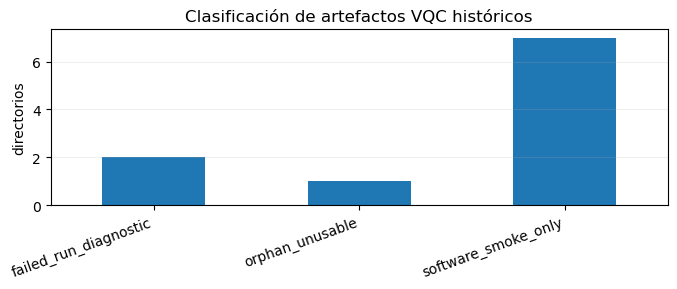

In [2]:
inventory = pd.DataFrame([{'familia': row['family'], 'región': row['region'], 'variante': row.get('variant', 'N/D'), 'clase de evidencia': row['evidence_class'], 'acceso TEST': row['test_access'], 'optimizer success': None if row['optimizer'] is None else row['optimizer'].get('success')} for row in audit['entries']])
display(inventory)
counts = inventory['clase de evidencia'].value_counts().sort_index(); fig, ax = plt.subplots(figsize=(7, 3)); counts.plot.bar(ax=ax); ax.set(ylabel='directorios', xlabel='', title='Clasificación de artefactos VQC históricos'); ax.grid(axis='y', alpha=.2); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

In [3]:
failed = pd.DataFrame([{'región': row['region'], 'clase': row['evidence_class'], 'éxito': row['optimizer']['success'], 'evaluaciones': row['optimizer']['objective_evaluations'], 'mensaje': row['optimizer']['message'], 'publicación inválida tras fallo': row.get('invalid_publication_after_failed_optimization', False)} for row in audit['entries'] if row['family'] == 'z4_vqc' and row['optimizer'] is not None])
display(failed)
print(audit['conclusion'])

,región,clase,éxito,evaluaciones,mensaje,publicación inválida tras fallo
0,high,failed_run_diagnostic,False,50,Return from COBYLA because the objective funct...,True
1,low,failed_run_diagnostic,False,50,Return from COBYLA because the objective funct...,True


No historical artifact supports a current quantum-advantage claim; failed/orphan z4 runs and conditional b/c smokes are preserved only in their explicit limited classes.


## Decisión actual
Los z4-VQC HIGH y LOW v2 terminaron COBYLA por límite de evaluaciones con `success=false`; sus métricas posteriores no son publicables bajo el gate actual. LOW v1 es huérfano sin reporte. Los híbridos son smokes condicionales P(b | b/c) y no scores b-vs-all.

Por lo tanto, hoy no existe evidencia para una afirmación de ventaja cuántica. Una futura candidatura VQC deberá usar el mismo contrato de datos, splits, companions, WP70 e incertidumbre que los modelos clásicos.